# 0. TFM

In [3]:
import numpy as np
import pandas as pd
import os
from scipy.stats import skew

# from surface_functions_2D import compute_surface_variance, compute_surface_roughness

In [4]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

In [5]:
avg_df_path = "../Simulations_2D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [6]:
avg_df[(avg_df["typenoise"] == "Columnar")]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor
avg_id,,,,,,,,,,,,
Columnar_delta0_L125_K20.0_T20000_M656,Columnar,0.000000,0,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",656,20000,"[0.0, 0.04339168315240173, 0.0542866907409231,...","[0.0, 0.04344233928968687, 0.05438920735034844...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L250_K20.0_T20000_M153,Columnar,0.000000,0,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",153,20000,"[0.0, 0.04370677936305243, 0.05489989394641664...","[0.0, 0.04372028053680627, 0.05492852261011782...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L500_K20.0_T20000_M31,Columnar,0.000000,0,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",31,20000,"[0.0, 0.04363913486127933, 0.05484272893896487...","[0.0, 0.04364239086410861, 0.05484897016838635...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L125_K20.0_T20000_M407,Columnar,1.373401,atan5,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",407,20000,"[0.0, 0.10162259388294839, 0.1276689958485225,...","[0.0, 0.10163986178791432, 0.12770533335378775...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L250_K20.0_T20000_M96,Columnar,1.373401,atan5,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",96,20000,"[0.0, 0.10205801305259561, 0.12837110553846212...","[0.0, 0.10206266339446121, 0.12838151903315792...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L500_K20.0_T20000_M19,Columnar,1.373401,atan5,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",19,20000,"[0.0, 0.10205084143959577, 0.1283351397168975,...","[0.0, 0.1020519431537211, 0.12833756909455707,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [7]:
avg_df[(avg_df["K"] == 10)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor
avg_id,,,,,,,,,,,,
TimeDep_delta0_L125_K10.0_T20000_M100,TimeDep,0.000000,0,10.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",100,20000,"[0.0, 0.017614619066983077, 0.0181916763437085...","[0.0, 0.017616153737050517, 0.0181942568912905...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K10.0_T20000_M61,TimeDep,0.000000,0,10.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",61,20000,"[0.0, 0.01764922025750833, 0.01818443094947499...","[0.0, 0.017649591325584173, 0.0181848437451244...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K10.0_T20000_M15,TimeDep,0.000000,0,10.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",15,20000,"[0.0, 0.017656908927665308, 0.0182061340107675...","[0.0, 0.017657081162194846, 0.0182063359371528...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K10.0_T20000_M100,TimeDep,1.373401,atan5,10.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",100,20000,"[0.0, 0.03366219976682197, 0.03510169129543746...","[0.0, 0.03366345544004608, 0.03510334167237543...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K10.0_T20000_M50,TimeDep,1.373401,atan5,10.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",50,20000,"[0.0, 0.0336410104734402, 0.03511699809219761,...","[0.0, 0.03364123789143709, 0.03511750863436797...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K10.0_T20000_M12,TimeDep,1.373401,atan5,10.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",12,20000,"[0.0, 0.033660612908811165, 0.0351512744780345...","[0.0, 0.03366073947361784, 0.03515140606678939...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [8]:
T = 20000
Ks = [10, 20]

In [9]:
t = avg_df["t"].iloc[0] # Careful! Here I assume every simulation has the same t...
ts=[(1,2), (9,10), (-2,-1)] # Beginning, halfway, end

In [10]:

# Scaling exponents
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"],
                         "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}}
             
delta_to_label = {"0": "EW", "atan5": "KPZ", "atan10": "KPZ"}

# Markers for different system sizes
markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

# Vertical lines' colors for different system sizes (roughness evolution plot)
vlinecolordict = {125: "tab:blue", 250: "tab:green", 500: "tab:orange", 1000: "tab:red"}


### Roughness

In [11]:
def plot_roughness_evolution_TIMEDEP(avg_df, T, Ks=Ks, save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    fig.supxlabel(r"$\log t$")
    fig.supylabel(r"$\log W(L,t)$")

    # Inset spanning lower-right quadrant of ax[0]
    ax0_inset = ax[0].inset_axes([0.52, 0.08, 0.45, 0.42])
    ax0_inset.set_xscale("log")   # semilogx inset: log x, linear y
    ax0_inset.tick_params(axis="both", labelsize=8)

    for i, (typenoise, typelabel) in enumerate(
        zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
    ):
        if i == 1:
            continue
            
        print("#", typenoise)

        for j, (delta, deltaname) in enumerate(
            zip([0, np.arctan(10)], ["0", "atan5"])
        ):

            print(deltaname)
            print("##", deltaname)

            mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )

            sub_df = avg_df[mask]

            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_roughness = row["mean_roughness"]
                L = row["L"]
                K = row["K"]

                ax[j].scatter(
                    t,
                    mean_roughness,
                    label=r"$L=$" + str(L),
                    marker=markerdict[L],
                )

                # Duplicate ax[0] data into inset, but semilogx
                if j == 0:
                    ax0_inset.scatter(
                        t,
                        mean_roughness**2,
                        marker=markerdict[L],
                        s=12,
                    )

            ax[j].set_xscale("log")
            ax[j].set_yscale("log")

    ax0_inset.set_xlabel(r"$t$", fontsize=8)
    ax0_inset.set_ylabel(r"$W^2(L,t)$", fontsize=8)

    ax0_inset.plot(t[1:-10:], np.log(t[1:-10:])/2500 + 0.0023,
                   label=r"1/2", linestyle="--", color="k")
    ax[1].loglog(t[1:3:], t[1:3:]**(0.24)/10, linestyle="--", color="k")
                   # label=r"$\beta\approx 0.3$",
    ax[1].loglog(t[-12:], t[-12:]**(1/2), linestyle="dotted", color="k")
                   #label=r"$\beta\approx 1/2$"

    ax0_inset.set_ylim(0.0015, 0.006)

    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan10$)", fontsize=12)

    ax[0].legend()
    ax[1].legend()

    plt.tight_layout()

    if save:
        plt.savefig("Figures/TFM/roughness_evolution_TIMEDEP.png", dpi=300)

    plt.show()

# TimeDep
0
## 0
atan5
## atan5


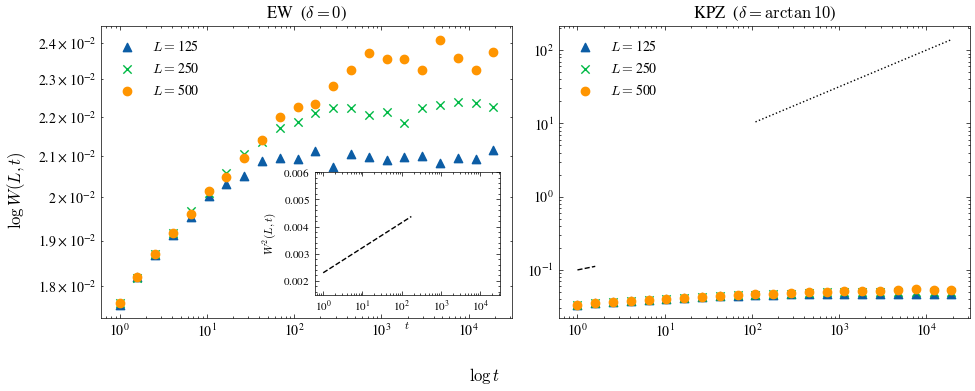

In [12]:
plot_roughness_evolution_TIMEDEP(avg_df, T, Ks=Ks)# save=True)

In [132]:
# Scaling exponents
z_dict = {"Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"Columnar": {"EW": 1, "KPZ": 1.07}}
alpha_s_dict = {"Columnar": {"EW": 1, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"Columnar": {"EW": 1, "KPZ": 1}} # anomalous scaling, only for columnar noise
beta_dict = {"Columnar": {"EW": 0.5, "KPZ": 0.786}}


In [133]:
beta_dict

{'Columnar': {'EW': 0.5, 'KPZ': 0.786}}

In [134]:
def plot_roughness_evolution_COLUMNAR(avg_df, T, Ks=Ks, save=False, show_sat_time=True):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    fig.supxlabel(r"$\log t$")
    fig.supylabel(r"$\log W(L,t)$")

    lastW_EW = []
    lastW_KPZ = []
    
    for i, (typenoise, typelabel) in enumerate(
        zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])):
        if i == 0:
            continue
            
        print("#", typenoise)

        for j, (delta, deltaname) in enumerate(
            zip([0, np.arctan(10)], ["0", "atan5"])
        ):

            print(deltaname)
            print("##", deltaname)

            mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )

            sub_df = avg_df[mask]

            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_roughness = row["mean_roughness"]
                L = row["L"]
                K = row["K"]
                
                if show_sat_time:
                    print("Last W(t)->", mean_roughness[-1])
                if deltaname == "0":
                    lastW_EW.append(mean_roughness[-1])
                if deltaname == "atan5":
                    lastW_KPZ.append(mean_roughness[-1])

                ax[j].scatter(
                    t,
                    mean_roughness,
                    label=r"$L=$" + str(L),
                    marker=markerdict[L],
                )
                
                if show_sat_time:
                    t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])
                    
                    print("\t", fr"$t_\star$({L}) = {t_cross}.")
                    
                    ax[j].vlines(t_cross, ymin=np.min(mean_roughness), ymax=np.max(mean_roughness),
                                 colors=vlinecolordict[L], linestyles='dotted')#,
                                 # label=r"$t_\star=$"+f"{np.round(t_cross,1)}")

            ax[j].set_xscale("log")
            ax[j].set_yscale("log")
        
    # ax[0].vlines(10, ymin=0.5, ymax=2, color="k", alpha=0.5)

    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)


    if show_sat_time:
        ax[0].loglog(t[1:10:], t[1:10:]**(beta_dict["Columnar"]["EW"])/16 , linestyle="--", color="k")
        ax[1].loglog(t[1:5:], t[1:5:]**(beta_dict["Columnar"]["EW"]) / 8, linestyle="--", color="k")
                       # label=r"$\beta\approx 0.7867$",
        ax[1].loglog(t[6:-11:], t[6:-11:]**(beta_dict["Columnar"]["KPZ"]) / 10, linestyle="--", color="k")
                       # label=r"$\beta\approx 0.786$",

    ax[0].legend()
    

    plt.tight_layout()

    if save:
        plt.savefig("Figures/TFM/roughness_evolution_COLUMNAR.png", dpi=300)

    plt.show()

    return lastW_EW, lastW_KPZ

In [135]:
beta_dict

{'Columnar': {'EW': 0.5, 'KPZ': 0.786}}

In [136]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": None, "KPZ": None}, "Columnar": {"EW": 1/600, "KPZ": 1/10}}

In [137]:
Ks

[10, 20]

# Columnar
0
## 0
Last W(t)-> 0.21726787834646172
	 $t_\star$(125) = 26.041666666666668.
Last W(t)-> 0.43860982448962677
	 $t_\star$(250) = 104.16666666666667.
Last W(t)-> 0.8501373804303435
	 $t_\star$(500) = 416.6666666666667.
atan5
## atan5
Last W(t)-> 1.7692086553896536
	 $t_\star$(125) = 71.08821635975183.
Last W(t)-> 3.7724830381356793
	 $t_\star$(250) = 182.47291577532087.
Last W(t)-> 8.052594013478652
	 $t_\star$(500) = 468.3809314197228.


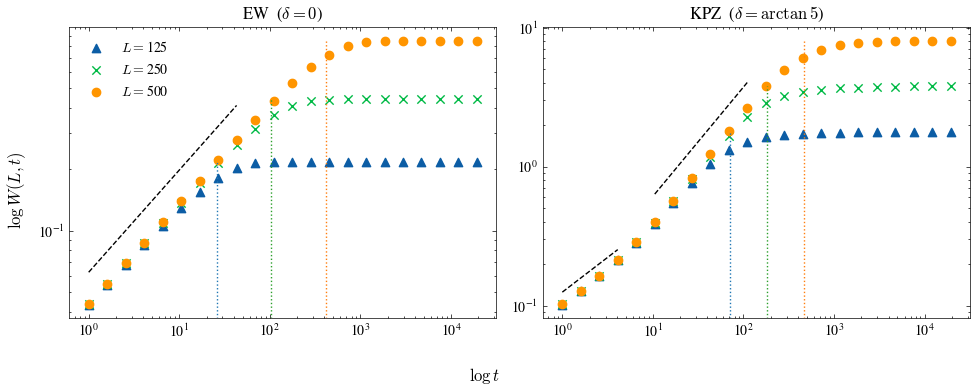

In [138]:
lastW_EW, lastW_KPZ = plot_roughness_evolution_COLUMNAR(avg_df, T, Ks=Ks, save=True)

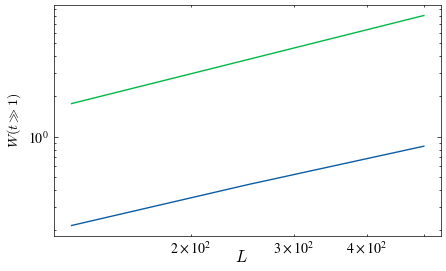

In [139]:
fig, ax = plt.subplots(1,1, figsize=(5,3))
ax.plot([125,250,500], lastW_EW)
ax.plot([125,250,500], lastW_KPZ)
ax.set_ylabel(r"$W(t\gg1)$")
ax.set_xscale("log")
ax.set_yscale("log")
fig.supxlabel("$L$")
# plt.tight_layout()
plt.show()

In [140]:
from scipy.stats import linregress

# Your X data
x_data = [125, 250, 500]

# Dictionary to store the results
results = {}

# Combine your data into a structure we can loop through
datasets = {
    "EW_Columnar": lastW_EW,
    "KPZ_Columnar": lastW_KPZ
}

# Compute linear regression for each dataset
for label, y_data in datasets.items():
    # linregress expects array-like inputs
    slope, intercept, r_value, p_value, std_err = linregress(np.log(x_data), np.log(y_data))
    
    results[label] = {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_value**2
    }
    
    print(f"{label}:")
    print(f"  Estimated Slope: {slope:.6f}")
    print(f"  R-squared:       {r_value**2:.4f}\n")

EW_Columnar:
  Estimated Slope: 0.984111
  R-squared:       0.9997

KPZ_Columnar:
  Estimated Slope: 1.093175
  R-squared:       1.0000



In [141]:
beta_dict["Columnar"]

{'EW': 0.5, 'KPZ': 0.786}

# Columnar
0
## 0
atan5
## atan5


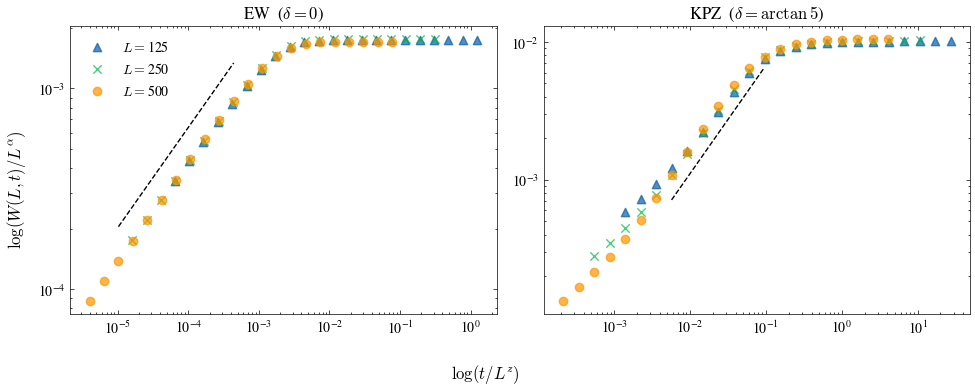

In [142]:
def plot_roughness_collapse_COLUMNAR(avg_df, T, Ks=Ks, save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    fig.supxlabel(r"$\log (t/L^z)$")
    fig.supylabel(r"$\log (W(L,t) / L^\alpha)$")

    typenoise = "Columnar"
    typelabel = "Columnar noise"
        
    print("#", typenoise)

    for j, (delta, deltaname) in enumerate(
        zip([0, np.arctan(10)], ["0", "atan5"])
    ):

        print(deltaname)
        print("##", deltaname)

        mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
        )

        sub_df = avg_df[mask]

        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
            
            z = z_dict[typenoise][delta_to_label[deltaname]]
            alpha = alpha_dict[typenoise][delta_to_label[deltaname]]

            # Collapse variables
            tLz = t / L**z
            WLa = mean_roughness / L**alpha

            ax[j].scatter(tLz, WLa, label=r"$L=$" + str(L), marker=markerdict[L], alpha=0.7)

        ax[j].set_xscale("log")
        ax[j].set_yscale("log")


    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)
    
    ax[0].loglog(t[3:-11:] / L**(z_dict["Columnar"]["EW"]),
                 (t[3:-11:] / L ** (alpha_dict["Columnar"]["EW"])) **(beta_dict["Columnar"]["EW"]) /350,
                 linestyle="--", color="k")
                 # label=r"$\beta_{EW}=1/2$"
    ax[1].loglog(t[8:-8:] / L**(z_dict["Columnar"]["KPZ"]),
                 (t[8:-8:] / L ** (alpha_dict["Columnar"]["KPZ"])) **(beta_dict["Columnar"]["KPZ"]) /100,
                 linestyle="--", color="k")
                   # label=r"$\beta\approx 0.7867$",

    ax[0].legend()
    # ax[1].legend()

    plt.tight_layout()

    if save:
        plt.savefig("Figures/TFM/roughness_collapse_COLUMNAR.png", dpi=300)

    plt.show()

plot_roughness_collapse_COLUMNAR(avg_df, T, Ks=Ks, save=True)

### Height-difference correlations

0
## 0
t: 2.56000128000064 Last G(r,t)-> 0.009590144332240818
t: 10.48000524000262 Last G(r,t)-> 0.03887152569387625
t: 42.94002147001074 Last G(r,t)-> 0.16072508333008653
t: 175.920087960044 Last G(r,t)-> 0.6513558831854828
atan5
## atan5
t: 2.56000128000064 Last G(r,t)-> 0.05395790733967252
t: 10.48000524000262 Last G(r,t)-> 0.3177869849162532
t: 42.94002147001074 Last G(r,t)-> 3.1405841515702813
t: 175.920087960044 Last G(r,t)-> 35.708237768607425


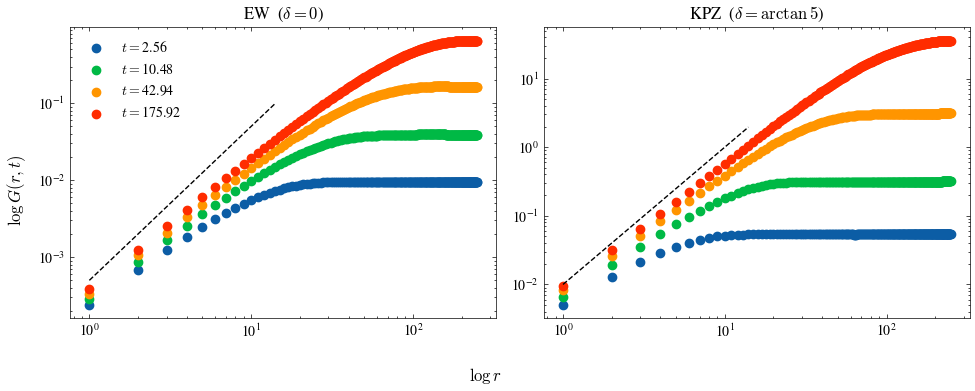

In [143]:
def plot_heightdifference_evolution(avg_df, L, T, tx, Ks=Ks, t_intervals=3, save=False):
    
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Height-difference correlation evolution under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$\log r$")
    fig.supylabel(r"$\log G(r,t)$")

    lastG_EW = []
    lastG_KPZ = []

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
    ):
        if i==0:
            continue

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):
        
            print(deltaname)
            print("##", deltaname)

            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]            
                mean_heightheight = row["mean_heightheight"]
                L = row["L"]
                K = row["K"]
                
                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:
                        
                        rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                        rrange = np.array(range(rlen))
                        
                        print("t:", t[ti], "Last G(r,t)->", mean_heightheight[ti,rlen//2])
                        if deltaname == "0":
                            lastG_EW.append(mean_heightheight[ti,rlen//2])
                        if deltaname == "atan5":
                            lastG_KPZ.append(mean_heightheight[ti,rlen//2])

                        ax[j].scatter(rrange[:rlen//2], mean_heightheight[ti,:rlen//2],
                                      label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])

            ax[j].set_xscale('log')
            ax[j].set_yscale('log')

    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

    # scaling as r^(2\alpha) = r^2 for alpha_loc approx 1 (EW/KPZ)
    ax[0].loglog(rrange[1:int(rlen/32)], rrange[1:int(rlen/32)]**(2*alpha_loc_dict["Columnar"]["EW"])/2000,
                 linestyle="--", color="k")
    ax[1].loglog(rrange[1:int(rlen/32)], rrange[1:int(rlen/32)]**(2*alpha_loc_dict["Columnar"]["KPZ"])/100,
                 linestyle="--", color="k")

    ax[0].legend()
    # ax[1].legend()

    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/heighdifference_evolution_{L}.png", dpi=300)
    plt.show()

    return lastG_EW, lastG_KPZ

lastG_EW, lastG_KPZ = plot_heightdifference_evolution(avg_df, 500, T, tx, Ks=Ks, t_intervals=3, save=True)

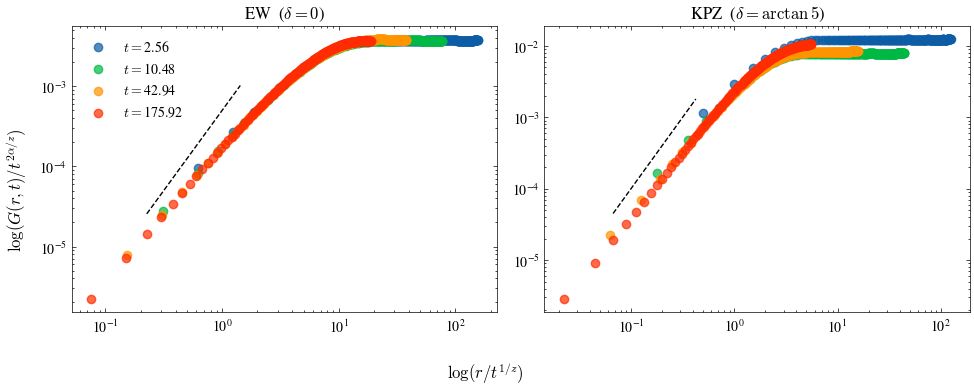

In [144]:
def plot_heightdifference_collapse(avg_df, L, T, tx, Ks=Ks, t_intervals=3, save=False):
    
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Height-difference correlation evolution under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$\log (r/ t^{1/z})$")
    fig.supylabel(r"$\log (G(r,t)/ t^{2\alpha/z})$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
    ):
        if i==0:
            continue

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]            
                mean_heightheight = row["mean_heightheight"]
                L = row["L"]
                K = row["K"]
                
                # Exponents
                z = z_dict[typenoise][delta_to_label[deltaname]]
                alpha = alpha_dict[typenoise][delta_to_label[deltaname]]

                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**z

                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                        rrange = np.array(range(rlen))

                        # Collapse variables
                        rt1z = rrange[:rlen//2] / t[ti]**(1/z)
                        Gt2az = mean_heightheight[ti,:rlen//2] / t[ti]**(2*alpha/z)

                        ax[j].scatter(rt1z, Gt2az, label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L], alpha=0.7)

            ax[j].set_xscale('log')
            ax[j].set_yscale('log')

            if j == 0:
                # scaling as r^(2\alpha) = r^2 for alpha_loc approx 1 (EW/KPZ)
                ax[0].loglog(rt1z[3:20], rt1z[3:20]**(2*alpha_loc_dict["Columnar"]["EW"])/2000,
                            linestyle="--", color="k")#, label=r"$\alpha_{loc}^{EW}=1$", 
            elif j == 1:
                ax[1].loglog(rt1z[3:20], rt1z[3:20]**(2*alpha_loc_dict["Columnar"]["KPZ"])/100,
                             linestyle="--", color="k")#, label=r"$\alpha_{loc}^{KPZ}=0.96$",

    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

    ax[0].legend()
    # ax[1].legend()

    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/heighdifference_collapse_{L}.png", dpi=300)
    plt.show()

plot_heightdifference_collapse(avg_df, 500, T, tx, Ks=Ks, t_intervals=3, save=True)

### Structure factor

In [145]:
tx

{'TimeDep': {'EW': None, 'KPZ': None},
 'Columnar': {'EW': 0.0016666666666666668, 'KPZ': 0.1}}

In [169]:
def plot_structurefactor_evolution_COLUMNAR(avg_df, L, T, tx, Ks=Ks, t_intervals=3, save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    fig.supxlabel(r"$\log k$")
    fig.supylabel(r"$\log S(k,t)$")
    
    for i, (typenoise, typelabel) in enumerate(
        zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])):
        if i == 0:
            continue
            
        print("#", typenoise)

        for j, (delta, deltaname) in enumerate(
            zip([0, np.arctan(5)], ["0", "atan5"])
        ):

            print(deltaname)
            print("##", deltaname)

            mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )

            sub_df = avg_df[mask]

            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_structurefactor = row["mean_structurefactor"]
                L = row["L"]
                K = row["K"]

                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        klen = mean_structurefactor.shape[1]
                        krange = 2*np.pi*np.fft.fftfreq(klen)
                        
                        # we only plot up to half due to nyquist
                        ax[j].scatter(krange[:int(klen/2)], mean_structurefactor[ti,:int(klen/2)],
                                        label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])

            ax[j].set_xscale("log")
            ax[j].set_yscale("log")

            if j == 0:
                ax[0].loglog(krange[10:int(klen/6)], krange[10:int(klen/6)]**(-2*alpha_s_dict["Columnar"]["EW"]-1)/1000,
                             linestyle="--", color="k")
            elif j == 1:
                ax[1].loglog(krange[15:int(klen/5)], krange[15:int(klen/5)]**(-2*alpha_s_dict["Columnar"]["KPZ"]-1) / 50,
                         linestyle="--", color="k")

    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

    ax[0].legend()
    # ax[1].legend()

    ax[1].set_ylim(0,1e2)
    
    plt.tight_layout()

    if save:
        plt.savefig("Figures/TFM/structurefactor_evolution_COLUMNAR.png", dpi=300)

    plt.show()


# Columnar
0
## 0
atan5
## atan5


/tmp/ipykernel_2816267/1341691637.py:67: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(0,1e2)


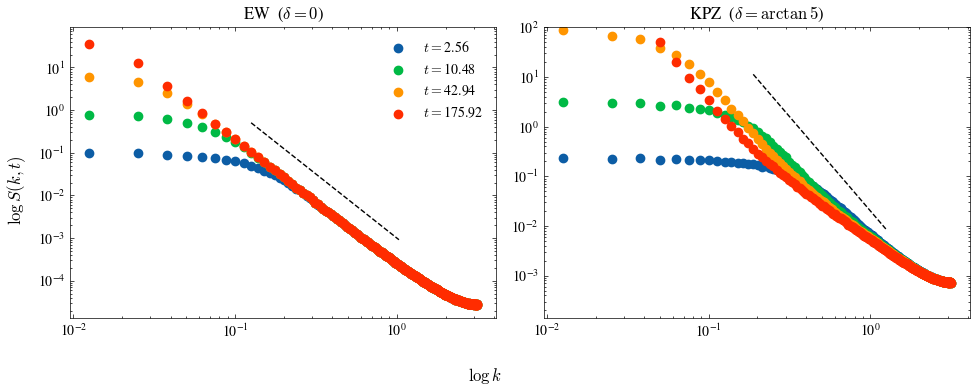

In [170]:
plot_structurefactor_evolution_COLUMNAR(avg_df, 500, T, tx, Ks=Ks, t_intervals=3, save=True)

# Columnar
0
## 0
atan5
## atan5


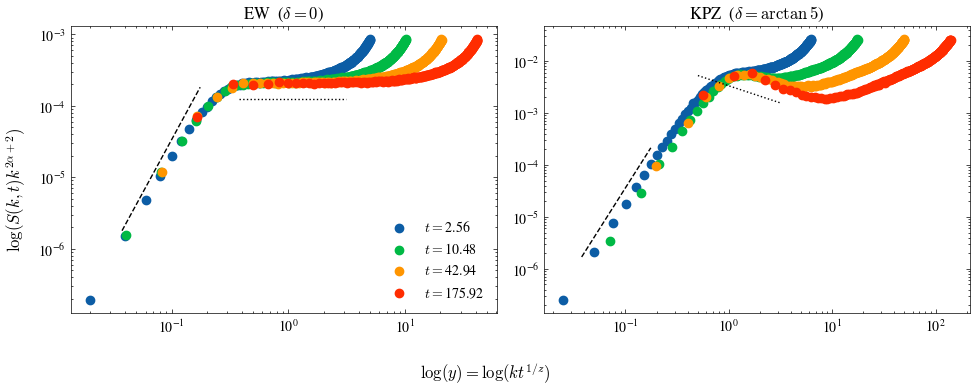

In [175]:
def plot_structurefactor_collapse_COLUMNAR(avg_df, L, T, tx, Ks=Ks, t_intervals=4, save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    fig.supxlabel(r"$\log(y)=\log (k t^{1/z})$")
    fig.supylabel(r"$\log (S(k,t) k^{2\alpha+2})$")

    typenoise = "Columnar"
    typelabel = "Columnar noise"
        
    print("#", typenoise)

    for j, (delta, deltaname) in enumerate(
        zip([0, np.arctan(5)], ["0", "atan5"])
    ):

        print(deltaname)
        print("##", deltaname)

        mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
        )

        sub_df = avg_df[mask]

        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_structurefactor = row["mean_structurefactor"]
            L = row["L"]
            K = row["K"]
            
            # Exponents
            z = z_dict[typenoise][delta_to_label[deltaname]]
            alpha = alpha_dict[typenoise][delta_to_label[deltaname]]
            # alpha_s = alpha_s_dict[typenoise][delta_to_label[deltaname]]

            # t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])
            t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])
            
            for ti in range(len(t))[::t_intervals]:

                if t[ti] > 0 and t[ti] < t_cross:

                    klen = mean_structurefactor.shape[1] # we only plot up to half due to nyquist
                    krange = 2*np.pi*np.fft.fftfreq(klen)

                    # Collapse variables
                    kt1z = krange[:int(klen/2)] * t[ti]**(1/z)
                    Sk2a = mean_structurefactor[ti,:int(klen/2)] * krange[:int(klen/2)]**(2*alpha+1)
                    
                    # we only plot up to half due to nyquist
                    ax[j].scatter(kt1z, Sk2a, marker=markerdict[L],
                                  label=f"$t=${np.round(t[ti],2)}")

            if j == 0:
                ax[0].loglog(krange[3:15], krange[3:15]**(2*alpha_dict["Columnar"]["EW"]+1)/30,
                             linestyle="--", color="k")
                ax[0].loglog(krange[30:250], krange[30:250]**(2*alpha_dict["Columnar"]["EW"]-2*alpha_s_dict["Columnar"]["EW"]) / 8000,
                             linestyle="dotted", color="k")
            elif j == 1:
                ax[1].loglog(krange[3:15], krange[3:15]**(2*alpha_dict["Columnar"]["KPZ"]+1) / 20,
                             linestyle="--", color="k")
                ax[1].loglog(krange[40:250], krange[40:250]**(2*alpha_dict["Columnar"]["KPZ"]-2*alpha_s_dict["Columnar"]["KPZ"]) / 300,
                             linestyle="dotted", color="k")
                
        ax[j].set_xscale("log")
        ax[j].set_yscale("log")


    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

    ax[0].legend()
    # ax[1].legend()

    plt.tight_layout()

    if save:
        plt.savefig("Figures/TFM/structurefactor_collapse_COLUMNAR.png", dpi=300)

    plt.show()

plot_structurefactor_collapse_COLUMNAR(avg_df, 500, T, tx, Ks=Ks, t_intervals=3, save=True)

## Fluctuations in L=500

#### Tracy-Widom preloading

In [181]:
## Loading TW pre-saved data
from scipy.interpolate import interp1d

data = np.loadtxt('../tw_data.csv', delimiter=',', skiprows=1)
s_vals = data[:, 0]
ds = s_vals[1] - s_vals[0]
tw_interp = {}

# Create interpolators for each TW distribution
for col, beta in enumerate([1, 2, 4], start=1):
    pdf = data[:, col]
    # Calculate moments from CSV to standardize
    mu = np.sum(s_vals * pdf) * ds
    sigma = np.sqrt(np.sum(s_vals**2 * pdf) * ds - mu**2)
    # Map to standardized coordinates
    tw_interp[beta] = interp1d((s_vals - mu) / sigma, pdf * sigma, 
                               kind='cubic', bounds_error=False, fill_value=0.0)


def normalized_tw_pdf(x, beta, grid_min=-20.0, grid_max=10.0, n_grid=200_000):
    """
    Standardized Tracy–Widom PDF (mean 0, variance 1) for beta=1,2,4.

    Returns f_std(x) where if Y ~ TW_beta, then X = (Y - mu)/sigma has PDF:
        f_std(x) = sigma * f_Y(sigma*x + mu)
    """
    TW = TracyWidom(beta=beta)

    # Build pdf function
    pdf_fn = lambda y: TW.pdf(y)

    mu, sigma = _estimate_moments_from_pdf(
        pdf_fn, grid_min=grid_min, grid_max=grid_max, n=n_grid
    )
    return TW.pdf(sigma * x + mu) * sigma

In [178]:
avg_df_path = "../Simulations_2D/fluctuations_N500_columnar.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [184]:
def plot_fluctuations_pdf(avg_df, L, T, tx, Ks, save=False):
    
    fig, ax = plt.subplots(1, 2, figsize=(10,5))
    # fig.suptitle("Fluctuation statistics under different noise types, for $L=$" + str(L))
    
    fig.supxlabel(r"$\varphi$")
    fig.supylabel(r"$P(\varphi)$")
    
    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])):

        if i == 0:
            continue
        
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):
    
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]
    
            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                
                varphis_full = row["varphis_full"]
                varphis_norm = (varphis_full - varphis_full.mean()) / varphis_full.std()
    
                print(f"Skewness ({typenoise}, {deltaname}):", skew(varphis_norm))
                
                # Data histogram
                nbins = 200
                hist, edges = np.histogram(varphis_norm, bins=nbins, density=True)
                centers = 0.5 * (edges[:-1] + edges[1:])
                
                ax[j].plot(centers, hist, marker='x', linestyle='None', label=r'Normalized $P(\varphi_i)$', markersize=6)
                
                # Gaussian N(0,1)
                xx = np.linspace(centers.min(), centers.max(), 1500)
                gauss_pdf = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * xx**2)
                ax[j].plot(xx, gauss_pdf, label='Gaussian N(0,1)')
                
                # Tracy–Widom PDFs
                ax[j].plot(xx, tw_interp[1](xx), label='GOE-TW')
                ax[j].plot(xx, tw_interp[2](xx), label='GUE-TW')
                ax[j].plot(xx, tw_interp[4](xx), label='GSE-TW')

                # ax[j,i].text(0.8, 0.95, fr'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)

                ax[j].set_xlim(-1.5,1.5)
                ax[j].set_ylim(0.2,0.45)
                
    # fig.suptitle(f"Columnar ($K=${Ks[1]})")      
    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)
    
    ax[0].legend()
    ax[1].legend()
    
    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/fluctuationPDFs_{L}.png", dpi=300)
    plt.show()

Skewness (Columnar, 0): 0.0282730299594109
Skewness (Columnar, atan5): 0.44743755458541773


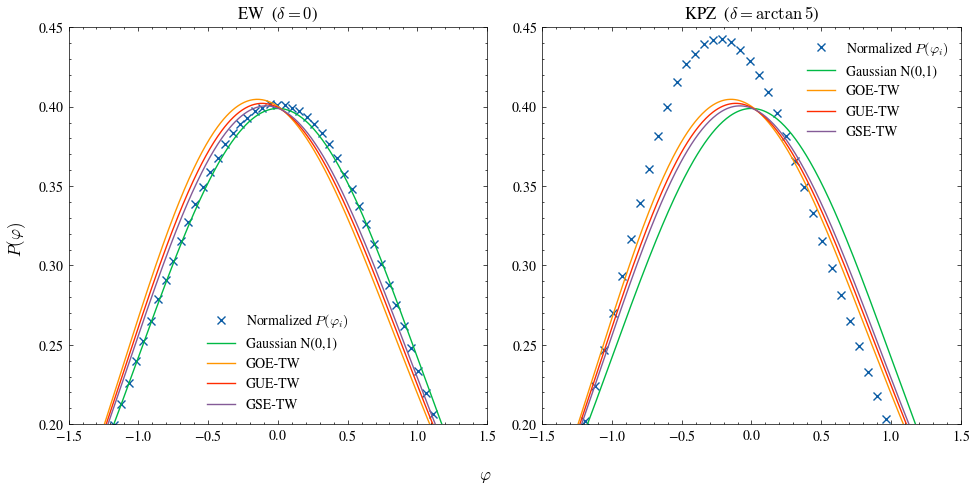

In [185]:
plot_fluctuations_pdf(avg_df, 500, T, None, Ks, save=True)

In [60]:
def plot_log_fluctuations_pdf(avg_df, L, T, tx, Ks, save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,5))
    # fig.suptitle("Fluctuation statistics under different noise types, for $L=$" + str(L))
    
    fig.supxlabel(r"$\varphi$")
    fig.supylabel(r"$\log P(\varphi)$")
    
    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])):

        if i==0:
            continue
            
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):
    
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]
    
            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
            
                varphis_full = row["varphis_full"]
    
                varphis_norm = (varphis_full - varphis_full.mean()) / varphis_full.std()
    
                # Data histogram
                nbins = 200
                hist, edges = np.histogram(varphis_norm, bins=nbins, density=True)
                centers = 0.5 * (edges[:-1] + edges[1:])
    
                ax[j].plot(centers, hist, marker='x', linestyle='None', label=r'Normalized $P(\varphi_i)$', markersize=6)
    
                # Gaussian N(0,1)
                xx = np.linspace(-6, 6, 1500)
                gauss_pdf = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * xx**2)
                ax[j].semilogy(xx, gauss_pdf, label='Gaussian N(0,1)')
    
                # Tracy–Widom PDFs
                ax[j].semilogy(xx, tw_interp[1](xx), label='GOE-TW')
                ax[j].semilogy(xx, tw_interp[2](xx), label='GUE-TW')
                ax[j].semilogy(xx, tw_interp[4](xx), label='GSE-TW')
    
                # ax[j,i].text(0.8, 0.95, fr'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)
    
                # ax[j].set_xlim(-1.5,1.5)
                # ax[j].set_ylim(0.2,0.41)
                
    # fig.suptitle(f"Columnar ($K=${Ks[1]})")      
    ax[0].set_title(r"EW  ($\delta=0$)", fontsize=12)
    ax[1].set_title(r"KPZ  ($\delta=\arctan5$)", fontsize=12)
    
    ax[0].legend()
    ax[1].legend()
                
    ax[0].set_xlim(-5,5)
    ax[1].set_xlim(-5,5)
    
    ax[0].set_ylim(1e-4,1)
    ax[1].set_ylim(1e-4,1)
    
    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/fluctuationLogPDFs_{L}.png", dpi=300)
    plt.show()

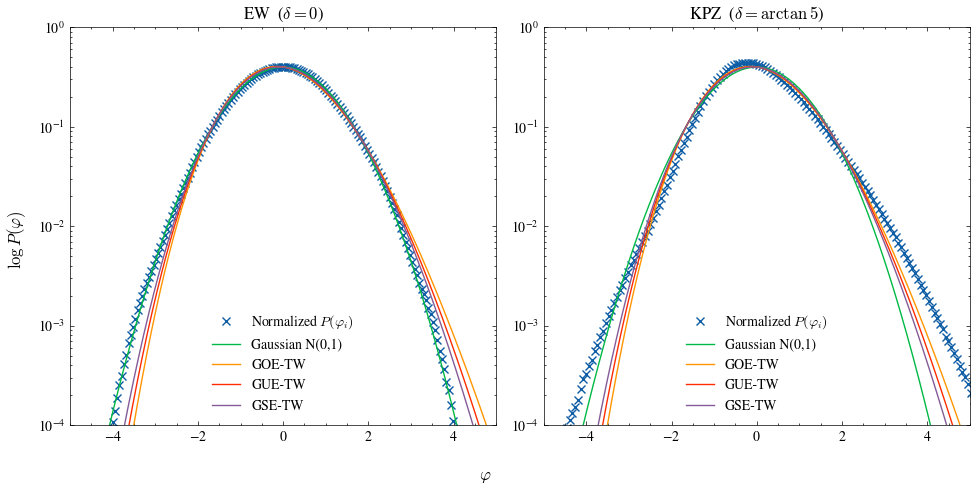

In [61]:
plot_log_fluctuations_pdf(avg_df, 500, T, None, Ks, save=True)